In [ ]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

import seaborn as sns 

import gower
from sklearn.cluster import DBSCAN

import statsmodels.formula.api as smf 
from scipy.stats import spearmanr, sem, pearsonr, norm, chi2

from copy import deepcopy

import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, PercentFormatter

from sklearn.metrics import mean_squared_error


# Utility functions and data processing 

In [ ]:
df_featimp = pd.read_csv("./data/feature_importance.csv")
df_featimp["pct_increase_in_error"] = 100 * (df_featimp["permuted_performance"] - df_featimp["baseline"]) / df_featimp["baseline"]

In [ ]:
df_featimp.feature.unique()

## Below, I'm including the code that was used to generate df_featimp, so you can see the logic if needed 


In [ ]:
# def oos_permutation_feature_importance(pipeline, df_train, df_test, features, outcome, model_label, n_iterations=10):
#     model = copy.deepcopy(pipeline).fit(X=df_train[features], y=df_train[outcome])
    
#     baseline = np.sqrt(mean_squared_error(model.predict(df_test[features])*100, df_test[outcome]*100))
    
#     iteration_list = []
#     permuted_performance_list = []
#     feature_list = []
    
#     for feature in tqdm(features):
#         iteration_list += list(range(n_iterations))
#         feature_list += [feature]*n_iterations
        
#         shuffled_performance = []
#         df_shuffle = copy.deepcopy(df_test)
#         for shuffle_iteration in range(n_iterations):
#             df_shuffle[feature] = np.random.RandomState(seed=shuffle_iteration).permutation(df_shuffle[feature].values)
#             shuffled_performance.append(np.sqrt(mean_squared_error(model.predict(df_shuffle[features])*100, df_test[outcome]*100)))
            
#         permuted_performance_list += shuffled_performance
    
#     df_featimp = pd.DataFrame({"baseline":baseline, "feature":feature_list, "iteration":iteration_list, "permuted_performance":permuted_performance_list})
#     df_featimp["importance"] = df_featimp["permuted_performance"] / df_featimp["baseline"]
#     df_featimp["model"] = model_label
    
#     return df_featimp



###### Get the feature importance values (30 iterations per feature)

# oos_ols_featimp = oos_permutation_feature_importance(dict_unfitted_models["ols"], df_paired_learn, df_paired_val, OOS_PRED_COLUMNS_PUNISHPARAMS+["control_itt_efficiency"], "treatment_itt_efficiency", "OLS", n_iterations=30)
# oos_rf_featimp = oos_permutation_feature_importance(dict_unfitted_models["rf"], df_paired_learn, df_paired_val, OOS_PRED_COLUMNS_PUNISHPARAMS+["control_itt_efficiency"], "treatment_itt_efficiency", "RF", n_iterations=30)
# oos_xgb_featimp = oos_permutation_feature_importance(dict_unfitted_models["xgb"], df_paired_learn, df_paired_val, OOS_PRED_COLUMNS_PUNISHPARAMS+["control_itt_efficiency"], "treatment_itt_efficiency", "XGB", n_iterations=30)
# oos_mlp_featimp = oos_permutation_feature_importance(dict_unfitted_models["mlp"], df_paired_learn, df_paired_val, OOS_PRED_COLUMNS_PUNISHPARAMS+["control_itt_efficiency"], "treatment_itt_efficiency", "MLP", n_iterations=30)
# oos_enet_featimp = oos_permutation_feature_importance(dict_unfitted_models["enet"], df_paired_learn, df_paired_val, OOS_PRED_COLUMNS_PUNISHPARAMS+["control_itt_efficiency"], "treatment_itt_efficiency", "E-net", n_iterations=30)


###### Put into a single dataframe and rename 
# df_featimp = pd.concat([oos_ols_featimp, oos_xgb_featimp, oos_enet_featimp, oos_rf_featimp, oos_mlp_featimp], ignore_index = True)

# df_featimp["feature"] = df_featimp["feature"].map({'CONFIG_playerCount':"# of players", 
#                                                                    'CONFIG_numRounds':"# of rounds",
#                                                                    'CONFIG_showNRounds':"Visibility of # of rounds", 
#                                                                    'CONFIG_MPCR':"Marginal per capita return",
#                                                                    'CONFIG_allOrNothing':'"All or Nothing" contributions', 
#                                                                    'CONFIG_chat':"Ability to chat", 
#                                                                    'CONFIG_defaultContribProp':"Default contribution vs withdrawal",
#                                                                    'CONFIG_rewardExists':"Ability to reward", 
#                                                                    'CONFIG_showOtherSummaries':"Peer outcome visibility",
#                                                                    'CONFIG_showPunishmentId':"Punisher/rewarder anonymity",
#                                                                    'CONFIG_punishmentCost':"Punishment cost",
#                                                                    'CONFIG_punishmentTech':"Punishment effectiveness",
#                                                                    "control_itt_efficiency":'Efficiency under control ("no punishment")'})


# Figure 4 code

## Elastic Net only 

/var/folders/wy/mdnzld0j5l517j2vxnpf3s980000gq/T/ipykernel_20718/1042971559.py:64: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  bars = sns.barplot(


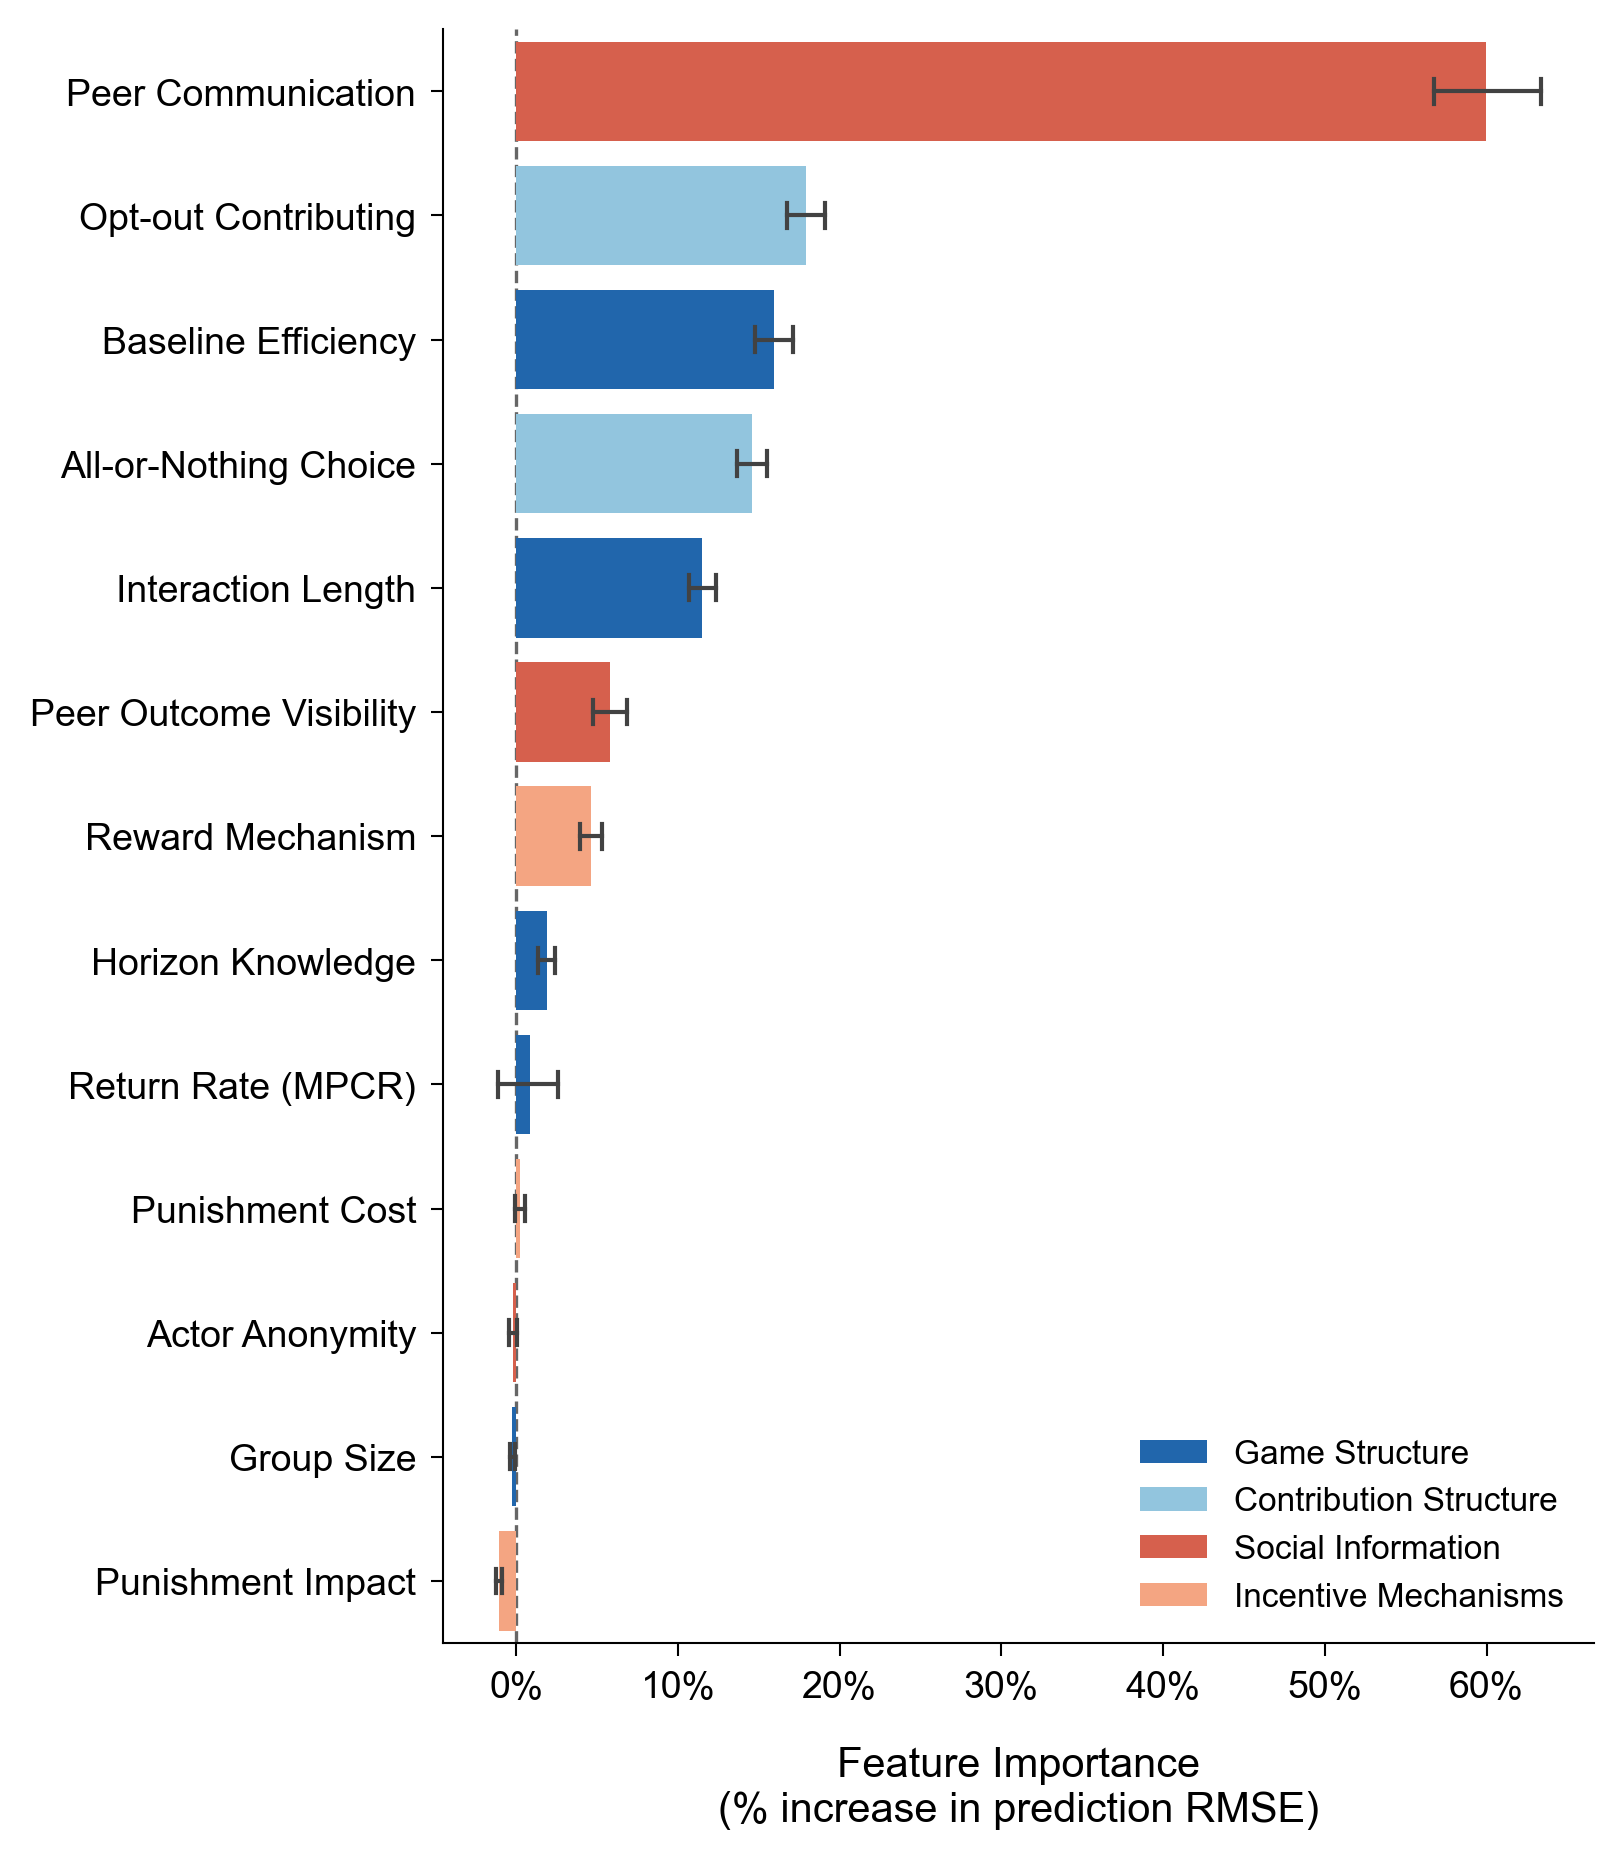

In [16]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
import pandas as pd

# Load and prepare data
df_featimp = pd.read_csv("./data/feature_importance.csv")
df_featimp["pct_increase_in_error"] = 100 * (df_featimp["permuted_performance"] - df_featimp["baseline"]) / df_featimp["baseline"]

# Style setup
plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['grid.alpha'] = 0.0

# Define categories and colors
category_colors = {
    'Game Structure': '#2166AC',         # Blue
    'Contribution Structure': '#92C5DE',    # Light blue
    'Social Information': '#D6604D',        # Red
    'Incentive Mechanisms': '#F4A582'       # Light red
}

# Create mapping of old to new feature names and their categories
feature_info = {
    '# of players': {'new_name': 'Group Size', 'category': 'Game Structure'},
    '# of rounds': {'new_name': 'Interaction Length', 'category': 'Game Structure'},
    'Visibility of # of rounds': {'new_name': 'Horizon Knowledge', 'category': 'Game Structure'},
    'Marginal per capita return': {'new_name': 'Return Rate (MPCR)', 'category': 'Game Structure'},
    '"All or Nothing" contributions': {'new_name': 'All-or-Nothing Choice', 'category': 'Contribution Structure'},
    'Default contribution vs withdrawal': {'new_name': 'Opt-out Contributing', 'category': 'Contribution Structure'},
    'Ability to chat': {'new_name': 'Peer Communication', 'category': 'Social Information'},
    'Peer outcome visibility': {'new_name': 'Peer Outcome Visibility', 'category': 'Social Information'},
    'Punisher/rewarder anonymity': {'new_name': 'Actor Anonymity', 'category': 'Social Information'},
    'Ability to reward': {'new_name': 'Reward Mechanism', 'category': 'Incentive Mechanisms'},
    'Punishment cost': {'new_name': 'Punishment Cost', 'category': 'Incentive Mechanisms'},
    'Punishment effectiveness': {'new_name': 'Punishment Impact', 'category': 'Incentive Mechanisms'},
    'Efficiency under control ("no punishment")': {'new_name': 'Baseline Efficiency', 'category': 'Game Structure'}
}

# Create figure
width_mm = 140
height_mm = 160
width_inches = width_mm / 25.4
height_inches = height_mm / 25.4
fig, ax = plt.subplots(figsize=(width_inches, height_inches), dpi=300)

# Create a copy of the dataframe and add new columns
df_plot = df_featimp.query("model == 'E-net'").copy()
df_plot['new_name'] = df_plot['feature'].map({k: v['new_name'] for k, v in feature_info.items()})
df_plot['category'] = df_plot['feature'].map({k: v['category'] for k, v in feature_info.items()})

# Get the order based on the mean values
means = df_plot.groupby('new_name')['pct_increase_in_error'].mean()
ordered_features = means.sort_values(ascending=False).index

# Create bar plot with adjusted error bars
bars = sns.barplot(
    x="pct_increase_in_error",
    y="new_name",
    data=df_plot,
    order=ordered_features,
    ax=ax,
    estimator='mean',
    errorbar=('ci', 68),  # Shows 1 standard error
    capsize=0.2,         # Very small cap size
    errwidth=1           # Thin error bars
)

# Color the bars according to category
for i, feature in enumerate(ordered_features):
    category = df_plot[df_plot['new_name'] == feature]['category'].iloc[0]
    bars.patches[i].set_facecolor(category_colors[category])

# Add reference line
plt.axvline(x=0, 
            linestyle="--", 
            color="#666666",
            linewidth=0.8,
            zorder=0)

# Style the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Adjust labels and ticks
plt.tick_params(axis="both", which='major', labelsize=9, length=3, width=0.5)
plt.ylabel("")
plt.xlabel("Feature Importance\n(% increase in prediction RMSE)", 
          fontsize=10, 
          labelpad=10)

# Format x-axis as percentage
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

# Create legend - stacked in one column
legend_elements = [Patch(facecolor=color, label=cat)
                  for cat, color in category_colors.items()]
# Position legend in the bottom left corner of the axes, single column
ax.legend(handles=legend_elements,
         loc='lower right',
         frameon=False,
         fontsize=8,
         ncol=1)  # Changed to 1 column


# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('feature_importance.pdf', 
            dpi=300, 
            bbox_inches='tight',
            metadata={'Creator': 'Matplotlib'})

#plt.close()

## All models 

In [ ]:
plt.figure(figsize=(5,10))
sns.pointplot(x="pct_increase_in_error", y="feature", 
              data=df_featimp, linestyles="", 
              order=df_featimp.groupby("feature")["pct_increase_in_error"].mean().sort_values(ascending=False).index,
              hue="model", hue_order=["E-net", "OLS", "RF", "MLP", "XGB"],
              dodge=0.5, palette=["#7DA5FA", "#1AFA00", "#FA7FBE", "#FAC37D", "#6D2DA8"])
plt.axvline(x=0, linestyle="--", color="black")
plt.tick_params(axis="both", labelsize=15)
plt.ylabel("")
plt.xlabel("Feature Importance\n(% increase in prediction RMSE)", fontsize=18)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.legend(frameon=False, fontsize=18, title="Model", title_fontsize=20)